![image.png](https://i.imgur.com/a3uAqnb.png)

# CLIP — Learning to See by Reading

###**Multimodal AI (Vision + Language)**



As humans our brains process information from multiple sensory inputs, eyes/vision for processing what is infront of us by reflecting light from the objects towards our retina, and ears can sense sound which give us more information about what we see, or making us aware about things outside of our eyesight, same for our smelling, licking and skin senses.

<div style="background-color: white; padding: 16px; border-radius: 8px; display: inline-block;">
  <img src="https://i.imgur.com/sz2Tvpk.png" alt="CLIP architecture" width="400">
</div>

It is very clear and no brainer that these multiple sensory inputs are really helpful for improving our perception of reality around us, and for a very long time AI models struggled with this problem as usually most models were made to recieve single modality(single type of input) like vision only or  text only while our brain work in a multimodal manner.


Our lab today deals with CLIP which is one of the major breakthroughs in multimodal AI created by OpenAI in 2021,It works by mapping text and vision to a shared embedding space using self supervised learning,

diagram pulled from their git repo:
https://github.com/openai/CLIP
  
<br>
<br>
<div style="background-color: white; padding: 16px; border-radius: 8px; display: inline-block;">
  <img src="https://raw.githubusercontent.com/openai/CLIP/main/CLIP.png" alt="CLIP architecture" width="900">
</div>

<br>
<br>

 By the end, you should have an intuitive answer to three questions:

1. **What is self-supervised learning, and why do we care?**
2. **How can a model learn useful image representations *without anyone labeling images*?**
3. **How does CLIP glue vision and language into a *single shared space*, and why is that so powerful?**

> We'll keep the code light so this runs comfortably on a free Colab CPU or T4 GPU.

---

### The one-sentence summary of CLIP

> CLIP learns, from **400 million (image, caption) pairs scraped from the web**, to put matching images and texts **close together** in a shared embedding space, and **non-matching ones far apart** — using *no human labels at all*.

That's it. Everything else in this notebook is exploring what falls out of that idea.

## 1. Why self-supervised learning?

Traditional image classifiers (think ResNet on ImageNet) require somebody — a human — to go through millions of images and assign each one a label like `"golden retriever"` or `"sea urchin"`. This has two big problems:

1) costly to label each data individually
2) less generalization

**Self-supervised learning** flips the script: instead of asking humans to supply the labels, we design a task where the **data supervises itself**.

### CLIP's self-supervision trick

CLIP looks at the internet and says: *"Whenever a web page has an image with a caption next to it, I'll treat the caption as the label."*

- No human annotator ever sat down to caption these images for CLIP.
- The captions are noisy, messy, multilingual, often weird — but there are **hundreds of millions of them**.
- Quantity + diversity beats clean labels.

This is why CLIP can recognize things ImageNet models have never heard of: obscure landmarks, Pokémon, memes, scientific diagrams. The web already "knew" about them, and CLIP just listened.

## 2. The core idea: contrastive learning 🧲

 (this notebook is not AI slop magnet emoji really represent what constrative loss is)




Imagine a batch of $N$ (image, caption) pairs. CLIP has two encoders:

- An **image encoder** $f_I$ (e.g., a Vision Transformer) that turns an image into a vector.
- A **text encoder** $f_T$ (a Transformer) that turns a caption into a vector.

Both vectors live in the **same** $d$-dimensional space (typically $d=512$).

For every image $i$ and caption $j$ in the batch, we compute the cosine similarity $\text{sim}(f_I(i),\, f_T(j))$. That gives us an $N \times N$ similarity matrix.

**Training objective — dead simple:**

- The $N$ values on the **diagonal** (matching pairs) should be **high**.
- The $N \cdot (N-1)$ **off-diagonal** values (mismatched pairs) should be **low**.

That's *contrastive* learning: you learn representations by contrasting what goes together against what doesn't. No class labels needed — the pairing itself is the supervision.

```
             text1  text2  text3  ...  textN
    image1  [ high  low    low    ...  low  ]   ← diagonal wants to win
    image2  [ low   high   low    ...  low  ]
    image3  [ low   low    high   ...  low  ]
    ...
    imageN  [ low   low    low    ...  high ]
```

After training on 400M pairs, the embedding space has a *beautiful* property:
**semantically similar things — across modalities — end up near each other.**

A photo of a cat 🐈, the word `"cat"`, the phrase `"a fluffy kitten on a sofa"`, and a cartoon drawing of a cat all land in roughly the same neighborhood.

That single property is what makes everything else possible.

##It's very hard to run training with the limited compute on google colab so this notebook would just  be a walkthrough around clip applications rather than actual training

## 3. Setup

We'll use the 🤗 `transformers` library, which has a ready-to-use CLIP. The base model (`openai/clip-vit-base-patch32`) is about 600 MB and runs fine on Colab's free tier.

In [ ]:
# Install dependencies (Colab usually has torch already)
!pip install -q transformers pillow matplotlib

In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Load CLIP

This single line downloads both the image encoder (a Vision Transformer) and the text encoder (a Transformer), plus their tokenizer and image processor.

In [ ]:
MODEL_NAME = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
model.eval()  # we're only doing inference, no training
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Total parameters: {n_params/1e6:.1f}M")
print(f"Embedding dimension: {model.config.projection_dim}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Total parameters: 151.3M
Embedding dimension: 512


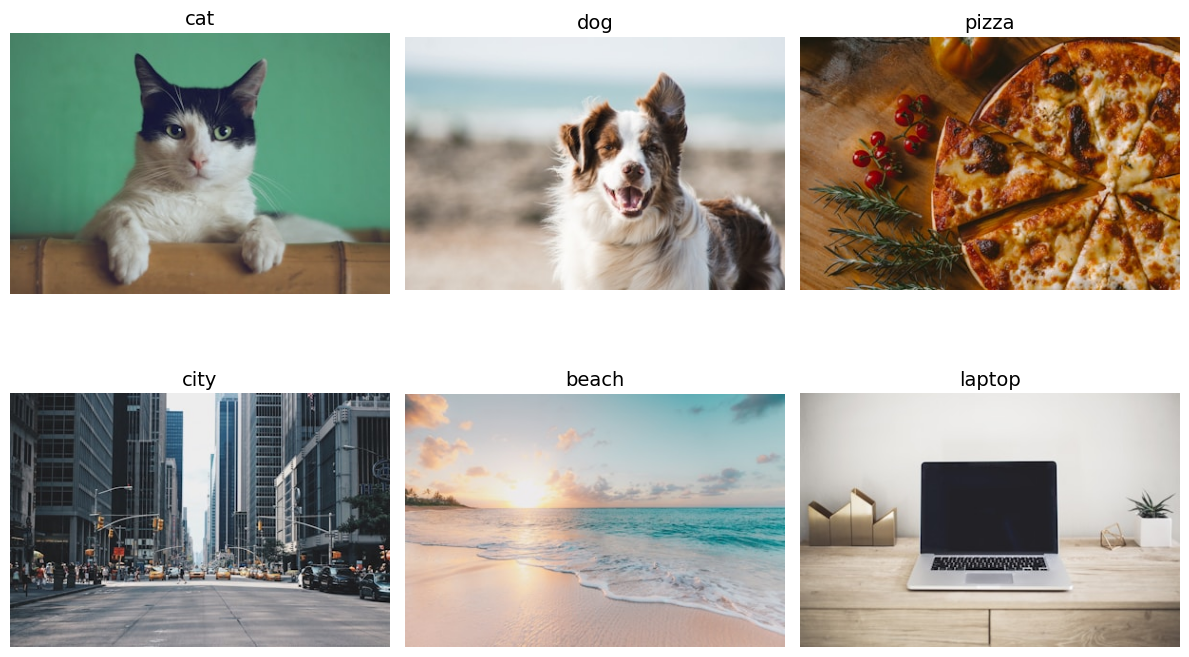

In [ ]:
def load_image(url_or_path):
    if url_or_path.startswith("http"):
        response = requests.get(url_or_path, timeout=15)
        return Image.open(BytesIO(response.content)).convert("RGB")
    return Image.open(url_or_path).convert("RGB")

# A small, diverse gallery — feel free to edit.
image_urls = {
    "cat":     "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400",
    "dog":     "https://images.unsplash.com/photo-1587300003388-59208cc962cb?w=400",
    "pizza":   "https://images.unsplash.com/photo-1513104890138-7c749659a591?w=400",
    "city":    "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=400",
    "beach":   "https://images.unsplash.com/photo-1507525428034-b723cf961d3e?w=400",
    "laptop":  "https://images.unsplash.com/photo-1496181133206-80ce9b88a853?w=400",
}

images = {name: load_image(url) for name, url in image_urls.items()}

# Preview them
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (name, img) in zip(axes.flat, images.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Encoding images and text into the shared space

Let's actually *see* the embedding idea in action. We'll:

1. Pass each image through the image encoder → get a 512-d vector.
2. Pass a few text descriptions through the text encoder → get 512-d vectors.
3. Confirm they really do live in the same space by comparing them directly.

Note how **nothing about the code distinguishes "image embeddings" from "text embeddings" once they're computed.** They're just vectors of the same shape.

In [ ]:
@torch.no_grad()
def encode_images(pil_images):
    inputs = processor(images=list(pil_images), return_tensors="pt").to(device)
    feats = model.get_image_features(**inputs)
    # Newer transformers versions return an object; older return a tensor directly.
    if hasattr(feats, "image_embeds"):
        feats = feats.image_embeds
    elif hasattr(feats, "pooler_output"):
        feats = feats.pooler_output
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

@torch.no_grad()
def encode_texts(texts):
    inputs = processor(text=list(texts), return_tensors="pt",
                       padding=True, truncation=True).to(device)
    feats = model.get_text_features(**inputs)
    if hasattr(feats, "text_embeds"):
        feats = feats.text_embeds
    elif hasattr(feats, "pooler_output"):
        feats = feats.pooler_output
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

image_names = list(images.keys())
image_feats = encode_images(images.values())
print("Image embeddings shape:", image_feats.shape)   # (N_images, 512)

texts = [
    "a photo of a cat",
    "a photo of a dog",
    "a slice of pizza",
    "a city skyline at sunset",
    "a beach with palm trees",
    "a laptop on a desk",
]
text_feats = encode_texts(texts)
print("Text embeddings shape: ", text_feats.shape)    # (N_texts, 512)

Image embeddings shape: torch.Size([6, 512])
Text embeddings shape:  torch.Size([6, 512])


 **Notice:** images become `(N, 512)` vectors, texts become `(M, 512)` vectors. Same dimension → same space → we can measure similarity *across* modalities.

### Computing the similarity matrix

Since both feature sets are already L2-normalized, the dot product **is** the cosine similarity.

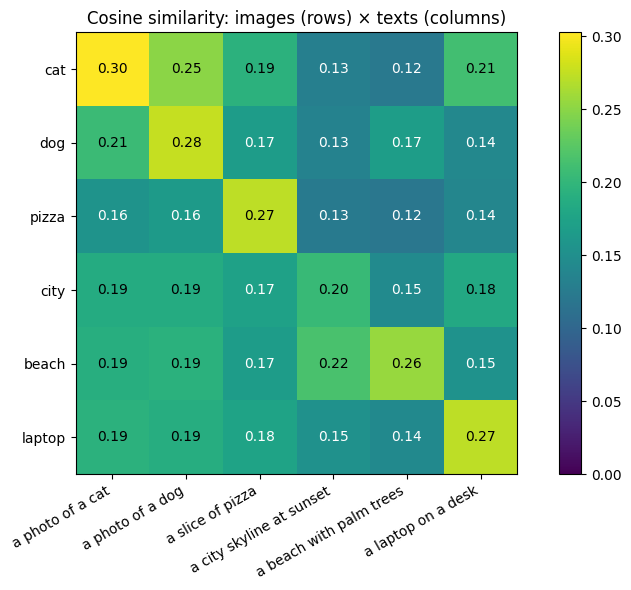

In [ ]:
similarity = (image_feats @ text_feats.T).cpu().numpy()

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(similarity, cmap="viridis", vmin=0, vmax=similarity.max())
ax.set_xticks(range(len(texts)))
ax.set_xticklabels(texts, rotation=30, ha="right")
ax.set_yticks(range(len(image_names)))
ax.set_yticklabels(image_names)
ax.set_title("Cosine similarity: images (rows) × texts (columns)")

# Annotate each cell with its value
for i in range(similarity.shape[0]):
    for j in range(similarity.shape[1]):
        ax.text(j, i, f"{similarity[i,j]:.2f}",
                ha="center", va="center",
                color="white" if similarity[i,j] < similarity.max()*0.6 else "black",
                fontsize=10)

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

 **Look at the diagonal.** The highest value in each row should be the text that actually describes that image — and the model has **never been told** which caption goes with which image at inference time. The alignment is a *property of the embedding space itself*.

That's the whole CLIP idea, visualized in one heatmap.

## 5. Zero-shot classification

Now the payoff. Normally, if you want a model to classify images into a new set of categories, you have to:

1. Collect labeled training images for each category.
2. Fine-tune a classifier.
3. Hope you didn't miss a category.

With CLIP, you just **write the category names in English.**

Here's the trick:
1. Turn each candidate label into a natural sentence: `"a photo of a {label}"`.
2. Encode all those sentences with the text encoder.
3. Encode the image.
4. Pick the label whose text embedding is closest.

No retraining. No fine-tuning. No labeled images. Just text.

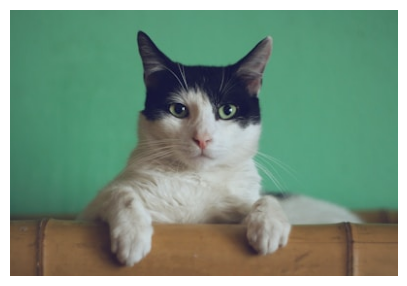

Zero-shot predictions:
  a cat                      97.3%  ██████████████████████████████████████
  a human                     1.6%  
  a dog                       0.6%  
  a horse                     0.2%  
  a piece of furniture        0.1%  
  a dragon                    0.1%  
  a fish                      0.1%  
  a plant                     0.0%  


In [ ]:
@torch.no_grad()
def zero_shot_classify(image, candidate_labels, template="a photo of a {}"):
    prompts = [template.format(label) for label in candidate_labels]
    img_feat = encode_images([image])            # (1, 512)
    txt_feats = encode_texts(prompts)            # (N_labels, 512)

    # Convert similarities to probabilities via softmax (with CLIP's learned temperature).
    logits = img_feat @ txt_feats.T * model.logit_scale.exp()
    probs = logits.softmax(dim=-1).cpu().numpy()[0]

    return dict(sorted(zip(candidate_labels, probs),
                       key=lambda x: -x[1]))

# Try it on the cat picture with a completely made-up label set.
test_image = images["cat"]
candidates = ["a cat", "a dog", "a horse", "a fish", "a dragon",
              "a piece of furniture", "a human", "a plant"]

results = zero_shot_classify(test_image, candidates)

plt.figure(figsize=(5, 5))
plt.imshow(test_image); plt.axis("off"); plt.show()

print("Zero-shot predictions:")
for label, prob in results.items():
    bar = "█" * int(prob * 40)
    print(f"  {label:25s} {prob*100:5.1f}%  {bar}")

Try changing the `candidates` list to whatever you want — **you define the label space at inference time**. This is something a standard ImageNet classifier fundamentally cannot do.

## 6. Text-to-image search

Another freebie that falls out of the shared embedding space: we can **search a collection of images with a text query**.

Just:
1. Pre-compute embeddings for every image in your collection (once).
2. At query time, embed the text query.
3. Return the images whose embeddings are closest to the query.

This is essentially how "Search by description" works in modern photo apps.

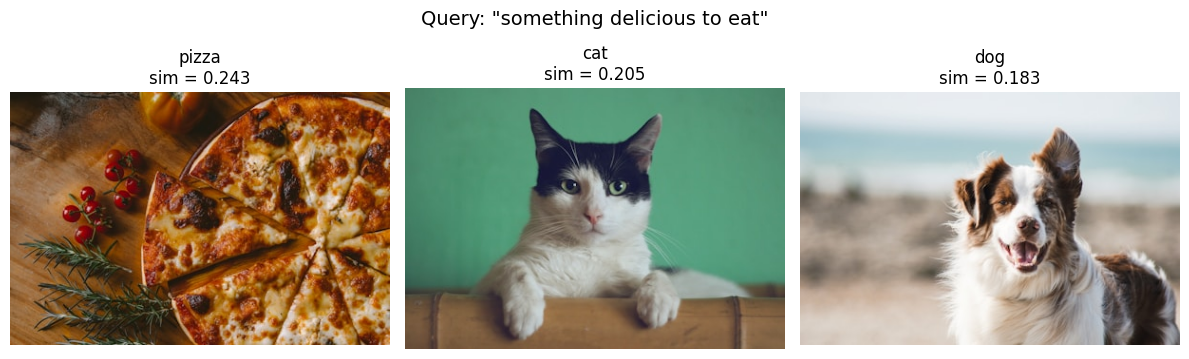

In [ ]:
def search_images_by_text(query, top_k=3):
    q_feat = encode_texts([query])               # (1, 512)
    sims = (q_feat @ image_feats.T).cpu().numpy()[0]
    ranked = np.argsort(-sims)[:top_k]
    return [(image_names[i], float(sims[i])) for i in ranked]

query = "something delicious to eat"
results = search_images_by_text(query, top_k=3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f'Query: "{query}"', fontsize=14)
for ax, (name, score) in zip(axes, results):
    ax.imshow(images[name])
    ax.set_title(f"{name}\nsim = {score:.3f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

👉 **Your turn.** Try these queries and see which images come up:

- `"a place I would go on vacation"`
- `"something I work on"`
- `"a furry animal"`
- `"urban environment"`

CLIP never saw these exact phrases paired with these exact images. It's **generalizing** from the abstract semantic structure it picked up during contrastive pretraining.

In [ ]:
#TODO

## 7. Why this matters for multimodal NLP

Let's zoom back out. What CLIP really gave the field was a **shared semantic space for vision and language**. That's a *building block*, not just a classifier. Here's what people do with that block:

| Application | How CLIP enables it |
|---|---|
| **Text-to-image generation** (DALL·E, Stable Diffusion) | Use CLIP's text embeddings to guide image synthesis. |
| **Image captioning with no paired data** | Decode from the shared space to language. |
| **Content moderation / safety filters** | Flag images matching unsafe text descriptions. |
| **Visual question answering** | Anchor vision features to a language-aware space. |
| **Open-vocabulary detection/segmentation** | Detect "any object you can name" rather than a fixed list. |

The bigger lesson: **once modalities share a space, they can talk to each other.** That's the whole philosophical point of multimodal representation learning, and CLIP is arguably the clearest instantiation of it.

### What CLIP is *not* great at


- **Counting and spatial reasoning.** It knows *what's* in an image, not *how many* or *where*.
- **Fine-grained distinctions** (bird species, specific car models) unless well-represented in web data.
- **Text inside images** (OCR-style tasks) — it reads text superficially and can be [*tricked by handwritten labels*](https://openai.com/research/multimodal-neurons) stuck on objects.
- **Bias.** It inherits whatever biases live in internet image-caption data.

### **Contributed by: Taha Alshatiri**